# 01 — The Four Generations of Search

This notebook walks through every era of search technology in one place, using real API calls.

| Generation | Method | Intuition |
|------------|--------|-----------|
| 1 | **Keyword (BM25)** | Match exact words, rank by term frequency |
| 2 | **Semantic (Dense kNN)** | Embed meaning into vectors, find geometrically close docs |
| 3 | **Hybrid (BM25 + kNN)** | Run both in parallel, normalise scores, combine — state of the art |
| 4 | **Agentic** | An LLM decides *how* to search, reasons over results, answers naturally |

**Stack:** Amazon Bedrock Titan V2 · Qdrant (cloud or in-memory) · rank_bm25 · Amazon Bedrock LLM

## Step 1 — Install & Import

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
    "boto3", "qdrant-client", "rank_bm25", "numpy", "matplotlib", "python-dotenv"])
print("Packages ready.")

Packages ready.


In [2]:
from dotenv import load_dotenv
load_dotenv('../../../.env')

import os, json, time, uuid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import boto3
from rank_bm25 import BM25Okapi
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "#0f1117",
    "axes.facecolor": "#1a1d27", "axes.edgecolor": "#3a3d4d",
    "axes.labelcolor": "#e0e0e0", "xtick.color": "#a0a0b0",
    "ytick.color": "#a0a0b0", "text.color": "#e0e0e0",
    "grid.color": "#2a2d3d", "grid.linestyle": "--", "grid.alpha": 0.5,
    "axes.titlesize": 12, "axes.labelsize": 10,
})
print("Imports OK")

Imports OK


## Step 2 — Configuration

In [3]:
AWS_REGION      = os.getenv("AWS_DEFAULT_REGION", "us-east-1")
EMBED_MODEL     = "amazon.titan-embed-text-v2:0"
LLM_MODEL       = "us.anthropic.claude-sonnet-4-6"
EMBED_DIM       = 1024
QDRANT_URL      = os.getenv("QDRANT_URL", "")
QDRANT_API_KEY  = os.getenv("QDRANT_API_KEY", "")

bedrock = boto3.client("bedrock-runtime", region_name=AWS_REGION)

def embed(text: str) -> np.ndarray:
    body = json.dumps({"inputText": text, "dimensions": EMBED_DIM, "normalize": True})
    resp = bedrock.invoke_model(modelId=EMBED_MODEL, body=body,
                                contentType="application/json", accept="application/json")
    return np.array(json.loads(resp["body"].read())["embedding"], dtype=np.float32)

def embed_batch(texts, delay=0.05):
    vecs = []
    for i, t in enumerate(texts):
        vecs.append(embed(t))
        time.sleep(delay)
        if (i+1) % 5 == 0:
            print(f"  {i+1}/{len(texts)} embedded")
    return np.vstack(vecs)

v = embed("test")
print(f"Embedding dim: {v.shape[0]}, norm: {np.linalg.norm(v):.4f}")

Embedding dim: 1024, norm: 1.0000


## Step 3 — Movie Corpus (20 Documents)

In [4]:
CORPUS = [
    {"id": 0,  "title": "Interstellar",            "genre": "sci-fi",   "description": "Astronauts travel through a wormhole near Saturn searching for a new habitable planet to save humanity from extinction."},
    {"id": 1,  "title": "The Martian",              "genre": "sci-fi",   "description": "An astronaut is stranded alone on Mars and must use science and ingenuity to survive until a rescue mission arrives."},
    {"id": 2,  "title": "Gravity",                  "genre": "sci-fi",   "description": "Two astronauts are adrift in space after their shuttle is destroyed and must fight to survive and return to Earth."},
    {"id": 3,  "title": "The Notebook",             "genre": "romance",  "description": "A poor but passionate young man falls in love with a rich girl in the 1940s South, fighting all odds to be together."},
    {"id": 4,  "title": "Pride & Prejudice",        "genre": "romance",  "description": "Elizabeth Bennet navigates issues of morality and marriage in 19th century England, falling for the proud Mr Darcy."},
    {"id": 5,  "title": "Romeo and Juliet",         "genre": "romance",  "description": "Two young lovers from feuding families secretly marry in Verona but fate conspires to keep them apart forever."},
    {"id": 6,  "title": "Se7en",                    "genre": "thriller", "description": "Two detectives hunt a serial killer who uses the seven deadly sins as his modus operandi in a dark rainy city."},
    {"id": 7,  "title": "Gone Girl",                "genre": "thriller", "description": "A husband becomes the prime suspect when his wife mysteriously disappears on their fifth wedding anniversary."},
    {"id": 8,  "title": "Knives Out",               "genre": "thriller", "description": "A sharp detective investigates the death of a wealthy crime novelist when the entire dysfunctional family is suspect."},
    {"id": 9,  "title": "The Hangover",             "genre": "comedy",   "description": "Three friends wake up in a wrecked Las Vegas hotel room with no memory of the night before and must find the missing groom."},
    {"id": 10, "title": "Planes Trains Automobiles", "genre": "comedy",  "description": "An uptight marketing executive is stuck travelling home for Thanksgiving with an overly friendly and disaster-prone shower curtain salesman."},
    {"id": 11, "title": "Little Miss Sunshine",     "genre": "comedy",   "description": "A dysfunctional family piles into a van and takes a hilarious cross-country road trip so their daughter can compete in a beauty pageant."},
    {"id": 12, "title": "The Shawshank Redemption", "genre": "drama",    "description": "A banker is wrongly convicted of murder and spends two decades in prison planning an elaborate escape."},
    {"id": 13, "title": "Forrest Gump",             "genre": "drama",    "description": "A slow-witted but kind-hearted man from Alabama unwittingly influences several historical events in 20th century America."},
    {"id": 14, "title": "A Beautiful Mind",         "genre": "drama",    "description": "The story of mathematician John Nash who makes a brilliant discovery and then descends into schizophrenia before an inspirational recovery."},
    {"id": 15, "title": "The Hunger Games",         "genre": "action",   "description": "In a dystopian future a teenage girl volunteers to take her sister's place in a televised fight to the death among children."},
    {"id": 16, "title": "Mad Max: Fury Road",       "genre": "action",   "description": "In a post-apocalyptic wasteland a woman rebels against a tyrannical ruler as she drives across a desert in search of her homeland."},
    {"id": 17, "title": "The Matrix",               "genre": "action",   "description": "A computer programmer discovers that reality is a simulation and joins a rebellion against the machines that have enslaved humanity."},
    {"id": 18, "title": "1984",                     "genre": "action",   "description": "In a totalitarian society where the government controls all information a man starts to secretly rebel against the oppressive regime."},
    {"id": 19, "title": "Inception",                "genre": "sci-fi",   "description": "A skilled thief who enters dreams is given the inverse task of planting an idea deep in a target's subconscious mind."},
]

GENRE_COLORS = {
    "sci-fi": "#7C4DFF", "romance": "#FF4081", "thriller": "#FF6D00",
    "comedy": "#FFD600",  "drama": "#00BCD4",   "action": "#69F0AE",
}

TEST_QUERIES = [
    "space exploration survival",
    "forbidden love story",
    "detective solving crime",
    "funny road trip",
    "dystopian future rebellion",
]

print(f"Corpus: {len(CORPUS)} movies  |  Genres: {set(m['genre'] for m in CORPUS)}")

Corpus: 20 movies  |  Genres: {'sci-fi', 'thriller', 'action', 'drama', 'comedy', 'romance'}


## Generation 1 — Keyword Search (BM25)

**Intuition:** A librarian who reads the words you say and looks for documents containing those exact words.  
BM25 (Best Match 25) scores each document by how often query terms appear, penalised by document length.  
Fast and interpretable — but completely blind to meaning. `"space exploration survival"` will miss a movie  
described as *"astronauts stranded on Mars"* because those exact words don't overlap.

In [5]:
corpus_tokens = [m["description"].lower().split() for m in CORPUS]
bm25 = BM25Okapi(corpus_tokens)

def bm25_search(query: str, top_k: int = 5):
    scores = bm25.get_scores(query.lower().split())
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)[:top_k]
    return [{"movie": CORPUS[idx], "score": float(score)} for idx, score in ranked]

print("BM25 results for all 5 queries:\n")
bm25_all_results = {}
for q in TEST_QUERIES:
    hits = bm25_search(q)
    bm25_all_results[q] = hits
    print(f"Query: '{q}'")
    for r in hits:
        print(f"  [{r['score']:.4f}] {r['movie']['title']} ({r['movie']['genre']})")
    print()

BM25 results for all 5 queries:

Query: 'space exploration survival'
  [2.5533] Gravity (sci-fi)
  [0.0000] Interstellar (sci-fi)
  [0.0000] The Martian (sci-fi)
  [0.0000] The Notebook (romance)
  [0.0000] Pride & Prejudice (romance)

Query: 'forbidden love story'
  [2.5533] A Beautiful Mind (drama)
  [2.3911] The Notebook (romance)
  [0.0000] Interstellar (sci-fi)
  [0.0000] The Martian (sci-fi)
  [0.0000] Gravity (sci-fi)

Query: 'detective solving crime'
  [5.3487] Knives Out (thriller)
  [0.0000] Interstellar (sci-fi)
  [0.0000] The Martian (sci-fi)
  [0.0000] Gravity (sci-fi)
  [0.0000] The Notebook (romance)

Query: 'funny road trip'
  [4.7821] Little Miss Sunshine (comedy)
  [0.0000] Interstellar (sci-fi)
  [0.0000] The Martian (sci-fi)
  [0.0000] Gravity (sci-fi)
  [0.0000] The Notebook (romance)

Query: 'dystopian future rebellion'
  [4.8856] The Hunger Games (action)
  [2.5533] The Matrix (action)
  [0.0000] Interstellar (sci-fi)
  [0.0000] The Martian (sci-fi)
  [0.0000] Gr

## Generation 2 — Semantic Search (Dense kNN)

**Intuition:** A librarian who understands *concepts*. Every document and query is embedded into a 1024-dimensional  
vector space by Amazon Bedrock Titan V2. Documents about the same concept end up geometrically close,  
even if they share zero words. `"space exploration survival"` finds *The Martian* via cosine similarity  
because both encode the same survival-in-space semantic cluster.

In [6]:
if QDRANT_URL:
    qc = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)
    print(f"Connected to Qdrant Cloud: {QDRANT_URL}")
else:
    qc = QdrantClient(":memory:")
    print("Using Qdrant in-memory")

COLL = "movies_gen2"
if COLL in [c.name for c in qc.get_collections().collections]:
    qc.delete_collection(COLL)
qc.create_collection(COLL, vectors_config=VectorParams(size=EMBED_DIM, distance=Distance.COSINE))

print(f"Embedding {len(CORPUS)} movie descriptions...")
descs = [m["description"] for m in CORPUS]
doc_vecs = embed_batch(descs)

points = [
    PointStruct(id=m["id"], vector=doc_vecs[i].tolist(),
                payload={"title": m["title"], "genre": m["genre"], "description": m["description"]})
    for i, m in enumerate(CORPUS)
]
qc.upsert(collection_name=COLL, points=points)
print(f"Indexed {len(points)} movies into Qdrant.")

Using Qdrant in-memory
Embedding 20 movie descriptions...


  5/20 embedded


  10/20 embedded


  15/20 embedded


  20/20 embedded
Indexed 20 movies into Qdrant.


In [7]:
def semantic_search(query: str, top_k: int = 5):
    q_vec = embed(query)
    hits = qc.query_points(collection_name=COLL, query=q_vec.tolist(),
                            limit=top_k, with_payload=True)
    return [{"movie": {"title": p.payload["title"], "genre": p.payload["genre"],
                       "description": p.payload["description"]},
             "score": p.score} for p in hits.points]

print("Semantic results for all 5 queries:\n")
semantic_all_results = {}
for q in TEST_QUERIES:
    hits = semantic_search(q)
    semantic_all_results[q] = hits
    print(f"Query: '{q}'")
    for r in hits:
        print(f"  [{r['score']:.4f}] {r['movie']['title']} ({r['movie']['genre']})")
    print()

Semantic results for all 5 queries:



Query: 'space exploration survival'
  [0.3687] Interstellar (sci-fi)
  [0.3211] The Martian (sci-fi)
  [0.2664] Gravity (sci-fi)
  [0.1156] A Beautiful Mind (drama)
  [0.1007] Mad Max: Fury Road (action)



Query: 'forbidden love story'
  [0.3703] Romeo and Juliet (romance)
  [0.2124] Pride & Prejudice (romance)
  [0.1805] 1984 (action)
  [0.1778] The Notebook (romance)
  [0.1716] Planes Trains Automobiles (comedy)



Query: 'detective solving crime'
  [0.3696] Knives Out (thriller)
  [0.3664] Se7en (thriller)
  [0.2195] Gone Girl (thriller)
  [0.2103] Inception (sci-fi)
  [0.1826] The Shawshank Redemption (drama)



Query: 'funny road trip'
  [0.4323] Little Miss Sunshine (comedy)
  [0.1730] Planes Trains Automobiles (comedy)
  [0.1222] A Beautiful Mind (drama)
  [0.1202] Mad Max: Fury Road (action)
  [0.1086] The Shawshank Redemption (drama)



Query: 'dystopian future rebellion'
  [0.3570] 1984 (action)
  [0.3486] The Matrix (action)
  [0.2964] The Hunger Games (action)
  [0.2959] Mad Max: Fury Road (action)
  [0.1537] Inception (sci-fi)



## Generation 3 — Hybrid Search (BM25 + kNN)

**Intuition:** Run keyword and semantic search simultaneously, normalise both score lists to [0,1],  
then blend with equal weights. Each method covers the other's blind spots:  
- Keyword catches exact SKUs, codes, and names that semantic embeddings dilute  
- Semantic catches synonyms, paraphrases, and conceptual queries that keyword misses  

Combined, hybrid consistently outperforms either alone — *the current state of the art*.

In [8]:
def min_max_norm(scores: list) -> list:
    s = np.array(scores, dtype=float)
    mn, mx = s.min(), s.max()
    if mx == mn:
        return [0.0] * len(scores)
    return ((s - mn) / (mx - mn)).tolist()

def hybrid_search(query: str, top_k: int = 5, alpha: float = 0.5):
    # BM25 over full corpus
    bm25_scores_raw = bm25.get_scores(query.lower().split()).tolist()
    bm25_norm = min_max_norm(bm25_scores_raw)

    # Semantic — get scores for all 20 docs
    q_vec = embed(query)
    sem_hits = qc.query_points(collection_name=COLL, query=q_vec.tolist(),
                                limit=len(CORPUS), with_payload=True)
    sem_by_id = {p.id: p.score for p in sem_hits.points}
    sem_scores_raw = [sem_by_id.get(m["id"], 0.0) for m in CORPUS]
    sem_norm = min_max_norm(sem_scores_raw)

    # Combine
    combined = [(i, alpha * sem_norm[i] + (1 - alpha) * bm25_norm[i]) for i in range(len(CORPUS))]
    combined.sort(key=lambda x: x[1], reverse=True)

    return [{"movie": CORPUS[idx], "score": float(score),
             "bm25_norm": bm25_norm[idx], "sem_norm": sem_norm[idx]}
            for idx, score in combined[:top_k]]

print("Hybrid results for all 5 queries:\n")
hybrid_all_results = {}
for q in TEST_QUERIES:
    hits = hybrid_search(q)
    hybrid_all_results[q] = hits
    print(f"Query: '{q}'")
    for r in hits:
        print(f"  [hybrid={r['score']:.3f}  bm25={r['bm25_norm']:.3f}  sem={r['sem_norm']:.3f}]  "
              f"{r['movie']['title']} ({r['movie']['genre']})")
    print()

Hybrid results for all 5 queries:



Query: 'space exploration survival'
  [hybrid=0.866  bm25=1.000  sem=0.732]  Gravity (sci-fi)
  [hybrid=0.500  bm25=0.000  sem=1.000]  Interstellar (sci-fi)
  [hybrid=0.438  bm25=0.000  sem=0.875]  The Martian (sci-fi)
  [hybrid=0.168  bm25=0.000  sem=0.336]  A Beautiful Mind (drama)
  [hybrid=0.149  bm25=0.000  sem=0.297]  Mad Max: Fury Road (action)



Query: 'forbidden love story'
  [hybrid=0.693  bm25=0.936  sem=0.449]  The Notebook (romance)
  [hybrid=0.628  bm25=1.000  sem=0.257]  A Beautiful Mind (drama)
  [hybrid=0.500  bm25=0.000  sem=1.000]  Romeo and Juliet (romance)
  [hybrid=0.274  bm25=0.000  sem=0.548]  Pride & Prejudice (romance)
  [hybrid=0.228  bm25=0.000  sem=0.457]  1984 (action)



Query: 'detective solving crime'
  [hybrid=1.000  bm25=1.000  sem=1.000]  Knives Out (thriller)
  [hybrid=0.495  bm25=0.000  sem=0.991]  Se7en (thriller)
  [hybrid=0.290  bm25=0.000  sem=0.580]  Gone Girl (thriller)
  [hybrid=0.277  bm25=0.000  sem=0.554]  Inception (sci-fi)
  [hybrid=0.239  bm25=0.000  sem=0.477]  The Shawshank Redemption (drama)



Query: 'funny road trip'
  [hybrid=1.000  bm25=1.000  sem=1.000]  Little Miss Sunshine (comedy)
  [hybrid=0.197  bm25=0.000  sem=0.394]  Planes Trains Automobiles (comedy)
  [hybrid=0.138  bm25=0.000  sem=0.275]  A Beautiful Mind (drama)
  [hybrid=0.135  bm25=0.000  sem=0.270]  Mad Max: Fury Road (action)
  [hybrid=0.122  bm25=0.000  sem=0.243]  The Shawshank Redemption (drama)



Query: 'dystopian future rebellion'
  [hybrid=0.905  bm25=1.000  sem=0.811]  The Hunger Games (action)
  [hybrid=0.748  bm25=0.523  sem=0.974]  The Matrix (action)
  [hybrid=0.500  bm25=0.000  sem=1.000]  1984 (action)
  [hybrid=0.404  bm25=0.000  sem=0.809]  Mad Max: Fury Road (action)
  [hybrid=0.182  bm25=0.000  sem=0.364]  Inception (sci-fi)



## Generation 4 — Agentic Search (LLM + Tool Use)

**Intuition:** Instead of executing a fixed retrieval pipeline, we give Amazon Bedrock LLM a `search_movies`  
tool and let it decide when to call it, how to interpret the results, and how to answer.  
The LLM can call the tool multiple times, reason about relevance, and synthesise a natural-language  
response with citations — not just a ranked list.

In [9]:
SEARCH_TOOL = {
    "name": "search_movies",
    "description": "Search the movie database using hybrid semantic+keyword search. Returns top matching movies.",
    "inputSchema": {
        "json": {
            "type": "object",
            "properties": {
                "query": {"type": "string", "description": "The search query"},
                "top_k": {"type": "integer", "description": "Number of results", "default": 3}
            },
            "required": ["query"]
        }
    }
}

def run_tool(tool_name: str, tool_input: dict) -> str:
    if tool_name == "search_movies":
        results = hybrid_search(tool_input["query"], top_k=tool_input.get("top_k", 3))
        lines = [f"{r['movie']['title']} ({r['movie']['genre']}) — score {r['score']:.3f}: {r['movie']['description']}"
                 for r in results]
        return "\n".join(lines)
    return "Tool not found."

def agentic_search(user_question: str, max_turns: int = 5) -> str:
    messages = [{"role": "user", "content": [{"text": user_question}]}]
    for _ in range(max_turns):
        resp = bedrock.converse(
            modelId=LLM_MODEL,
            messages=messages,
            system=[{"text": "You are a knowledgeable movie recommendation assistant. "
                              "Use the search_movies tool to find relevant movies, then give a warm, "
                              "helpful answer citing specific titles and why they match."}],
            toolConfig={"tools": [{"toolSpec": SEARCH_TOOL}]}
        )
        stop_reason = resp["stopReason"]
        output_msg  = resp["output"]["message"]
        messages.append(output_msg)

        if stop_reason == "end_turn":
            for block in output_msg["content"]:
                if "text" in block:
                    return block["text"]
            return str(output_msg)

        if stop_reason == "tool_use":
            tool_results = []
            for block in output_msg["content"]:
                if "toolUse" in block:
                    tool_use = block["toolUse"]
                    result_text = run_tool(tool_use["name"], tool_use["input"])
                    tool_results.append({
                        "toolResult": {
                            "toolUseId": tool_use["toolUseId"],
                            "content": [{"text": result_text}]
                        }
                    })
            if tool_results:
                messages.append({"role": "user", "content": tool_results})
    return "Max turns reached."


agentic_questions = [
    "I want to watch something about surviving alone in a harsh environment. What do you recommend?",
    "Suggest a movie with a clever plot twist involving crime.",
]

for question in agentic_questions:
    print(f"Question: {question}")
    answer = agentic_search(question)
    print(f"Agent: {answer}")
    print("-" * 70)

Question: I want to watch something about surviving alone in a harsh environment. What do you recommend?


Agent: Here are some great picks for you! 🏕️🌍

---

🥇 **The Martian** *(Sci-Fi)*
This is a **perfect match** for your mood! Astronaut Mark Watney is accidentally left behind on Mars and must survive completely alone using only his wits, science knowledge, and limited resources. It's tense, clever, and surprisingly funny — a must-watch for survival fans.

---

🥈 **Mad Max: Fury Road** *(Action)*
While not a solo survival story, it captures the brutal struggle to survive in a scorched, unforgiving wasteland. It's a visually stunning, adrenaline-pumping ride through a post-apocalyptic desert world.

---

🥉 **The Hunger Games** *(Action/Dystopian)*
Katniss Everdeen is thrown into a deadly arena and must rely on her survival instincts in the wild to outlast her opponents. It blends wilderness survival with high-stakes drama beautifully.

---

**My top pick for you is definitely *The Martian*** — it's the most direct match to your theme of one person surviving alone in an extremely harsh env

Agent: Great news — I've got a perfect pick for you! 🎬

**Knives Out (2019)** is an absolute must-watch if you love crime stories with a clever twist! Here's why it stands out:

- 🔍 **Brilliant, subversive storytelling**: Director Rian Johnson plays with the classic "whodunit" formula in a wonderfully unexpected way. Just when you think you know where the story is going, the plot pulls the rug right out from under you.
- 🎭 **An outstanding ensemble cast**: Featuring Daniel Craig, Ana de Armas, Chris Evans, and more, every character is a suspect with motives, secrets, and sharp wit.
- 🏡 **A twisty mystery at its core**: A famous crime novelist is found dead, and a brilliant detective (the eccentric Benoit Blanc) must untangle a web of lies within a deeply dysfunctional wealthy family.

What makes it truly special is that it **flips the whodunit genre on its head** — the "twist" isn't just a cheap surprise, but a clever, layered revelation that recontextualizes everything you've seen. It

## Visualization — All 4 Generations Side by Side

For the query `"dystopian future rebellion"` we show the top-5 results from each generation  
as a horizontal bar chart coloured by genre. This makes the difference in retrieval quality visible.

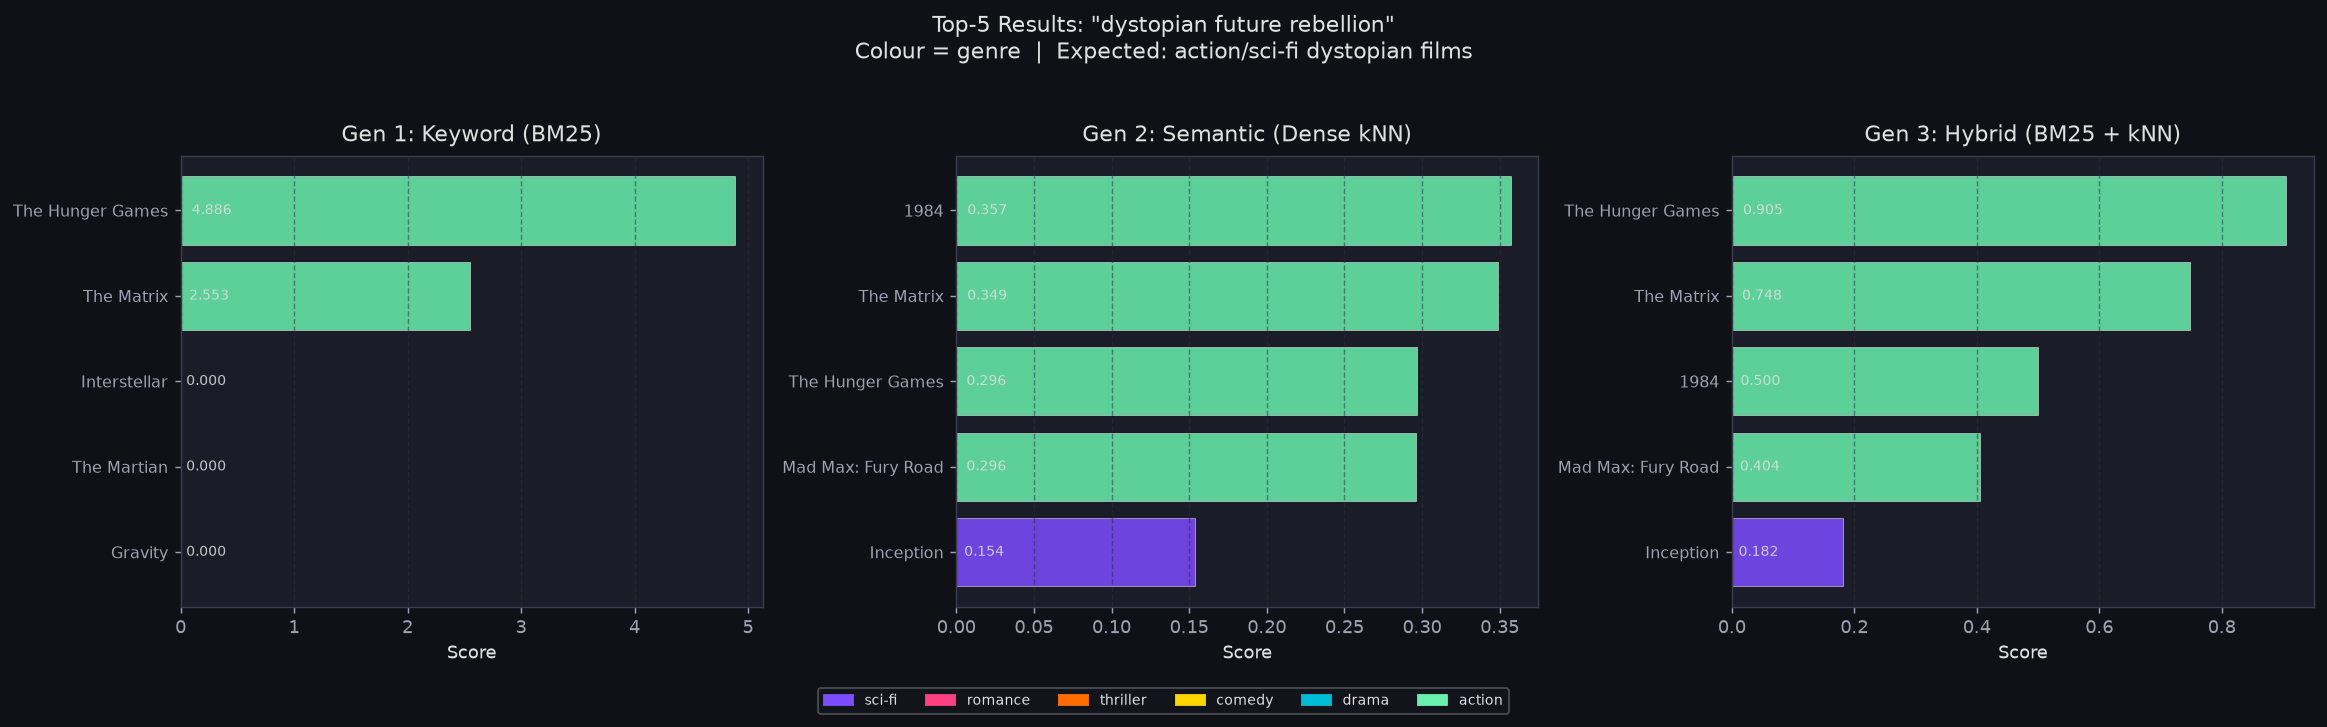

Saved: 01_four_generations.png


In [10]:
VIZ_QUERY = "dystopian future rebellion"

viz_data = [
    ("Gen 1: Keyword (BM25)",        bm25_all_results.get(VIZ_QUERY, bm25_search(VIZ_QUERY))),
    ("Gen 2: Semantic (Dense kNN)",   semantic_all_results.get(VIZ_QUERY, semantic_search(VIZ_QUERY))),
    ("Gen 3: Hybrid (BM25 + kNN)",    hybrid_all_results.get(VIZ_QUERY, hybrid_search(VIZ_QUERY))),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, results) in zip(axes, viz_data):
    titles_list  = [r["movie"]["title"][:25] for r in results]
    scores_list  = [r["score"] for r in results]
    colors_list  = [GENRE_COLORS.get(r["movie"]["genre"], "#aaaaaa") for r in results]

    bars = ax.barh(range(len(titles_list)), scores_list, color=colors_list, alpha=0.85,
                   edgecolor="white", linewidth=0.3)
    ax.set_yticks(range(len(titles_list)))
    ax.set_yticklabels(titles_list, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Score")
    ax.set_title(title, pad=8)
    ax.grid(axis="x")
    for i, score in enumerate(scores_list):
        ax.text(score * 0.01 + max(scores_list) * 0.01, i, f"{score:.3f}",
                va="center", fontsize=8, alpha=0.85)

patches = [mpatches.Patch(color=c, label=g) for g, c in GENRE_COLORS.items()]
fig.legend(handles=patches, loc="lower center", ncol=6, framealpha=0.3,
           fontsize=8, bbox_to_anchor=(0.5, -0.06))

fig.suptitle(f'Top-5 Results: "{VIZ_QUERY}"\nColour = genre  |  Expected: action/sci-fi dystopian films',
             fontsize=12, y=1.03)
fig.tight_layout()
plt.savefig("01_four_generations.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: 01_four_generations.png")

---
## NVIDIA Perspective — Four Generations of Search

### Where NVIDIA fits in this stack

| Generation | NVIDIA Tool | Speedup |
|---|---|---|
| **Keyword (BM25)** | OpenSearch + cuVS | 9.4× faster index builds vs CPU |
| **Semantic (dense kNN)** | **CAGRA** (GPU graph ANN) | Outperforms HNSW even at batch size 10 |
| **Hybrid** | Qdrant + cuVS backend | Official NVIDIA × Qdrant GPU partnership |
| **Agentic** | NeMo Retriever + NIM | Production RAG microservices with TensorRT-LLM |

### CAGRA vs HNSW (DEEP-100M, H100 GPU)

> *CAGRA outperforms HNSW in raw search performance even for a batch size of 10 vectors* — NVIDIA

- **95×** faster index training vs CPU HNSW
- **3×** faster small-batch queries
- **Same format** — build on GPU, convert to HNSW for CPU deployment

### NeMo Retriever (agentic layer)
- `llama-nemotron-embed-vl-1b-v2` — multimodal embedding (text + scanned PDFs)
- `llama-nemotron-rerank-vl-1b-v2` — second-stage reranker
- `nemoretriever-parse` — document extraction from PDFs/images
- All served as NIM microservices with TensorRT-LLM optimisation

**References:**
- [NVIDIA cuVS overview](https://developer.nvidia.com/topics/ai/generative-ai/cuvs)
- [Accelerating Vector Search with GPU Indexes](https://developer.nvidia.com/blog/accelerating-vector-search-using-gpu-powered-indexes-with-rapids-raft/)
- [RAG 101: Demystifying RAG Pipelines](https://developer.nvidia.com/blog/rag-101-demystifying-retrieval-augmented-generation-pipelines/)
- [NeMo Retriever](https://www.nvidia.com/en-us/ai-data-science/products/nemo/)


## Summary Comparison

In [11]:
print("\n" + "=" * 75)
print("FOUR GENERATIONS OF SEARCH — COMPARISON")
print("=" * 75)
rows = [
    ("Gen 1: Keyword (BM25)",       "Fast, zero infra",       "Misses synonyms & concepts",       "Lexical match"),
    ("Gen 2: Semantic (Dense kNN)", "Understands meaning",    "Slow index, misses exact codes",   "Cosine distance in 1024-D"),
    ("Gen 3: Hybrid",               "Best of both worlds",    "Two pipelines to maintain",        "BM25 + kNN, score fusion"),
    ("Gen 4: Agentic",              "Natural lang, flexible", "Highest cost & latency",           "LLM + tool use"),
]
print(f"{'Method':<30} {'Strength':<25} {'Weakness':<35} {'Mechanism'}")
print("-" * 75)
for row in rows:
    print(f"{row[0]:<30} {row[1]:<25} {row[2]:<35} {row[3]}")
print("=" * 75)

qc.delete_collection(COLL)
print("\nQdrant collection cleaned up.")


FOUR GENERATIONS OF SEARCH — COMPARISON
Method                         Strength                  Weakness                            Mechanism
---------------------------------------------------------------------------
Gen 1: Keyword (BM25)          Fast, zero infra          Misses synonyms & concepts          Lexical match
Gen 2: Semantic (Dense kNN)    Understands meaning       Slow index, misses exact codes      Cosine distance in 1024-D
Gen 3: Hybrid                  Best of both worlds       Two pipelines to maintain           BM25 + kNN, score fusion
Gen 4: Agentic                 Natural lang, flexible    Highest cost & latency              LLM + tool use

Qdrant collection cleaned up.
